/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities 

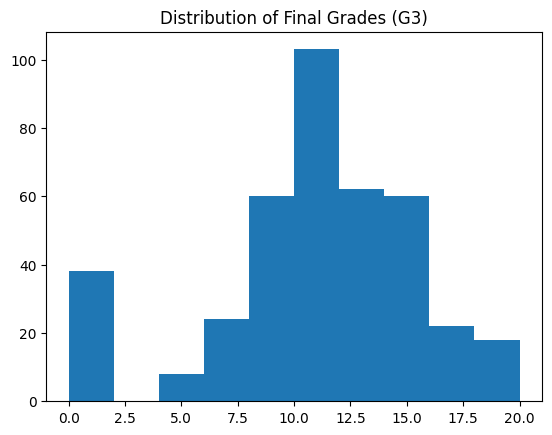

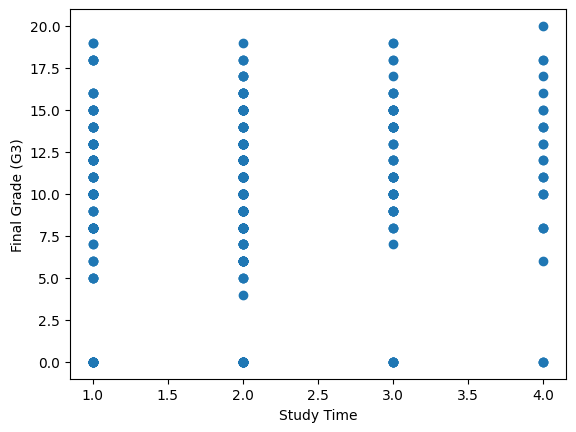

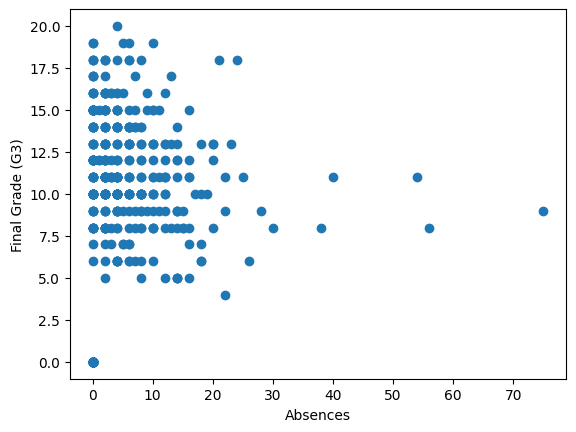

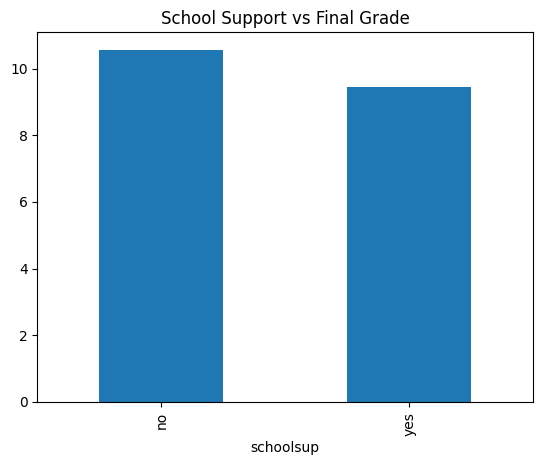

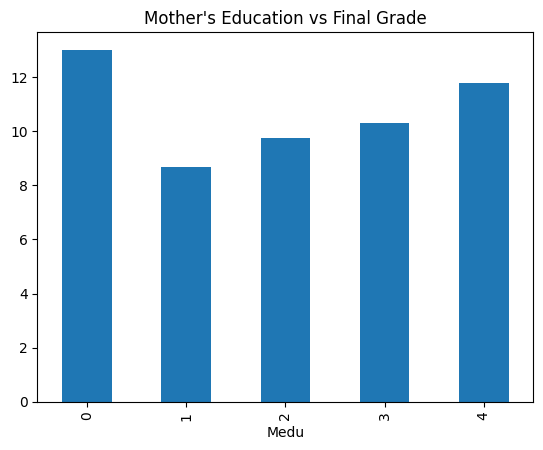

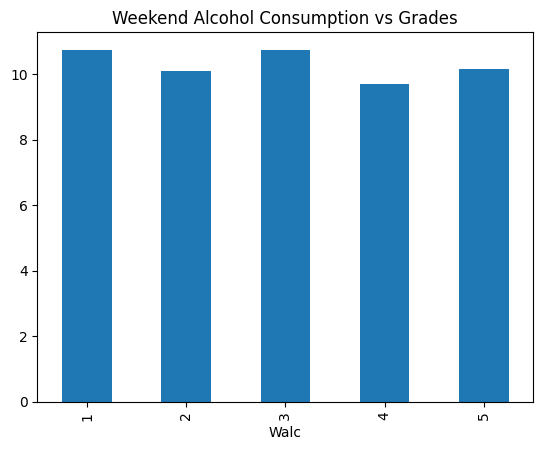

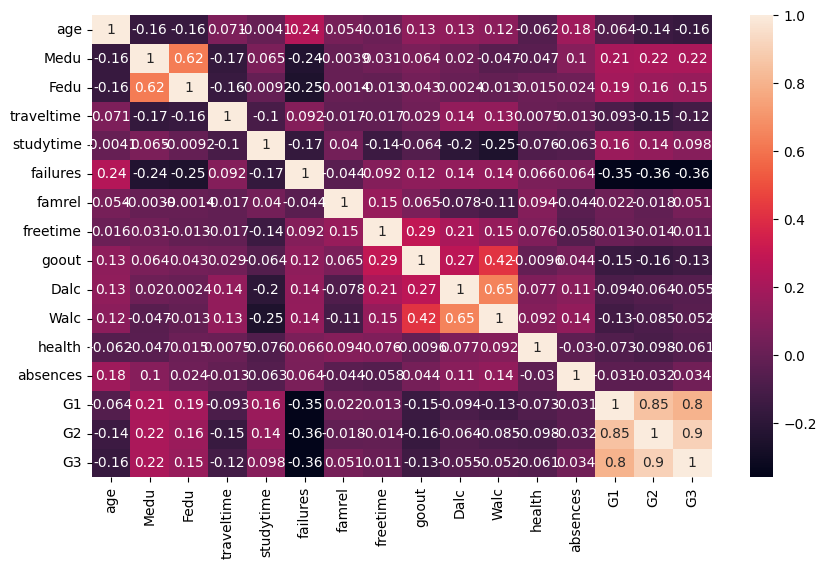

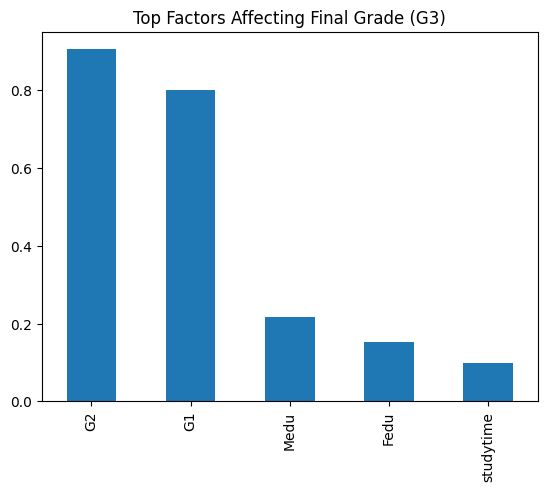

MAE: 1.0246835443037974
R2 Score: 0.8577917896102272


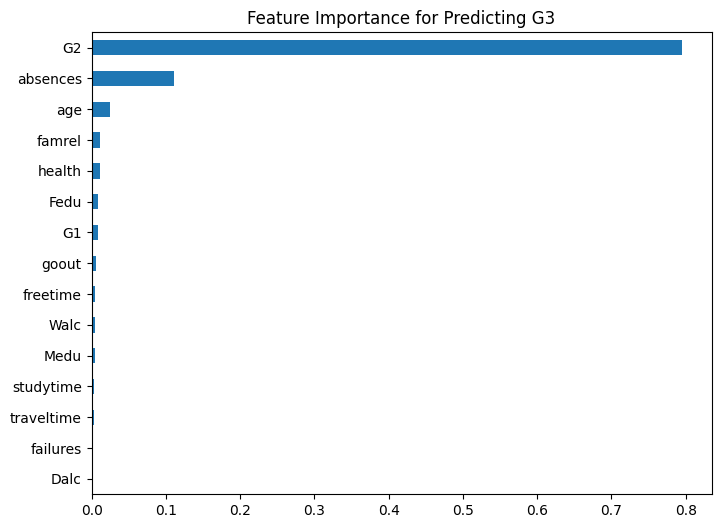

In [7]:

#What factors most influence student final grades (G3)?
#Objective: To analyze student academic performance using statistical analysis

# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


df = pd.read_csv("/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv")
df.head()

df.info()
df.describe()

df["G3"].describe()

plt.hist(df["G3"])
plt.title("Distribution of Final Grades (G3)")
plt.show()


#Relationship #1 
plt.scatter(df["studytime"], df["G3"])
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.show()

#Relationship #2 
plt.scatter(df["absences"], df["G3"])
plt.xlabel("Absences")
plt.ylabel("Final Grade (G3)")
plt.show()


#Do students with support perform better?
df.groupby("schoolsup")["G3"].mean().plot(kind="bar")
plt.title("School Support vs Final Grade")
plt.show()

#Family Education 
df.groupby("Medu")["G3"].mean().plot(kind="bar")
plt.title("Mother's Education vs Final Grade")
plt.show()


#Alcohol Impact 
df.groupby("Walc")["G3"].mean().plot(kind="bar")
plt.title("Weekend Alcohol Consumption vs Grades")
plt.show()


#Correlaion Heatmap 
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()


numeric_df.corr()["G3"].sort_values(ascending=False) #What affects final grade?


corr_g3 = numeric_df.corr()["G3"].sort_values(ascending=False)

corr_g3[1:6].plot(kind="bar")
plt.title("Top Factors Affecting Final Grade (G3)")
plt.show()



#Key Insights:

#1. G1 and G2 are the strongest predictors of final grade (G3), showing strong academic consistency over time.
#2. Absences negatively impact performance, suggesting attendance plays a key role in outcomes.
#3. Study time shows a positive relationship with academic success.
#4. Alcohol consumption appears negatively correlated with performance.
#5. Family and school support show weaker but noticeable influence.




y = df["G3"]
X = numeric_df.drop(columns=["G3"]) #remove G1 and G2 first

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Train

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test) #Predictions

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance for Predicting G3")
plt.show()


#Machine Learning Insight:
#The Random Forest model shows that prior academic performance (G1 and G2) and attendance-related features are the strongest predictors of final grade (G3). Behavioral and lifestyle factors contribute but are less influential compared to academic history.
